<a href="https://colab.research.google.com/github/angielopez03/Computacion_Paralela/blob/main/notebook/udacity_cs344_hw1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!apt-get update && apt-get install -y --fix-missing libopencv-dev

!git clone https://github.com/depctg/udacity-cs344-colab

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [18]:
# Arquitectura GPU moderna
!find /content/udacity-cs344-colab/src/ -name "*.cmake" -o -name "CMakeLists.txt" | \
  xargs grep -l "compute_" | \
  xargs sed -i 's/compute_[0-9]*/compute_75/g; s/sm_[0-9]*/sm_75/g'

# Constantes de OpenCV 4
!sed -i 's/CV_LOAD_IMAGE_COLOR/cv::IMREAD_COLOR/g' /content/udacity-cs344-colab/src/HW1/HW1.cpp
!sed -i 's/CV_LOAD_IMAGE_GRAYSCALE/cv::IMREAD_GRAYSCALE/g' /content/udacity-cs344-colab/src/HW1/HW1.cpp
!sed -i 's/CV_BGR2RGBA/cv::COLOR_BGR2RGBA/g' /content/udacity-cs344-colab/src/HW1/HW1.cpp

In [19]:
kernel_code = '''#include "utils.h"

__global__
void rgba_to_greyscale(const uchar4* const rgbaImage,
                       unsigned char* const greyImage,
                       int numRows, int numCols)
{
  // Calcula en qué columna y fila está el thread
  int col = blockIdx.x * blockDim.x + threadIdx.x;
  int row = blockIdx.y * blockDim.y + threadIdx.y;

  if (col >= numCols || row >= numRows) return;

  int idx = row * numCols + col;   // Convierte posición 2D a índice 1D (como un arreglo)
  uchar4 rgba = rgbaImage[idx];
  float grey = .299f * rgba.x + .587f * rgba.y + .114f * rgba.z;
  greyImage[idx] = (unsigned char)grey;
}

void your_rgba_to_greyscale(const uchar4 * const h_rgbaImage, uchar4 * const d_rgbaImage,
                            unsigned char* const d_greyImage, size_t numRows, size_t numCols)
{
  const dim3 blockSize(16, 16, 1);
  const dim3 gridSize((numCols + 15) / 16, (numRows + 15) / 16, 1);
  rgba_to_greyscale<<<gridSize, blockSize>>>(d_rgbaImage, d_greyImage, numRows, numCols);

  cudaDeviceSynchronize(); checkCudaErrors(cudaGetLastError());
}
'''

with open('/content/udacity-cs344-colab/src/HW1/student_func.cu', 'w') as f:
    f.write(kernel_code)

print("Kernel guardado correctamente")

Kernel guardado correctamente


In [20]:
!mkdir -p /content/udacity-cs344-colab/build
%cd /content/udacity-cs344-colab/build
!cmake -DOpenCV_DIR=/usr/lib/x86_64-linux-gnu/cmake/opencv4 ../src
!make HW1
!bin/HW1 ../src/HW1/cinque_terre.gold

/content/udacity-cs344-colab/build
CMake Deprecation Warning at CMakeLists.txt:8 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value.  Or, use the <min>...<max> syntax
  to tell CMake that the project requires at least <min> but has been updated
  to work with policies introduced by <max> or earlier.


CMake Warning (dev) at CMakeLists.txt:12 (find_package):
  Policy CMP0146 is not set: The FindCUDA module is removed.  Run "cmake
  --help-policy CMP0146" for policy details.  Use the cmake_policy command to
  set the policy and suppress this warning.

This warning is for project developers.  Use -Wno-dev to suppress it.

CMake Deprecation Warning at HW3/CMakeLists.txt:8 (cmake_minimum_required):
  Compatibility with CMake < 3.10 will be removed from a future version of
  CMake.

  Update the VERSION argument <min> value.  Or, use the <min>...<max> syntax
  to tell CMake that the project 

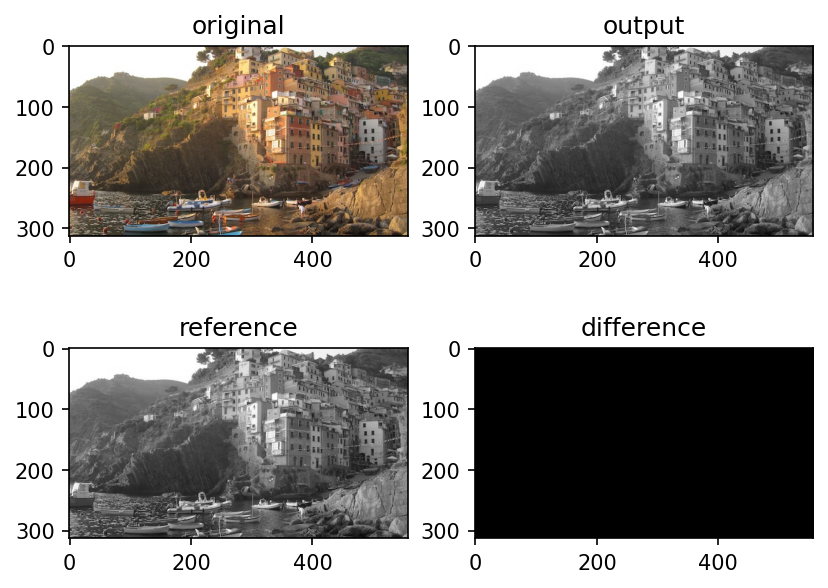

In [21]:
import matplotlib.pyplot as plt
_,ax = plt.subplots(2,2, dpi=150)
ax[0][0].imshow(plt.imread("../src/HW1/cinque_terre_small.jpg"))
ax[0][0].set_title("original")
ax[0][0].grid(False)
ax[0][1].imshow(plt.imread("HW1_output.png"), cmap='gray')
ax[0][1].set_title("output")
ax[0][1].grid(False)
ax[1][0].imshow(plt.imread("HW1_reference.png"), cmap='gray')
ax[1][0].set_title("reference")
ax[1][0].grid(False)
ax[1][1].imshow(plt.imread("HW1_differenceImage.png"), cmap='gray')
ax[1][1].set_title("difference")
ax[1][1].grid(False)
plt.show()